In [22]:
import pandas as pd
import numpy as np
from pathlib import Path
pd.set_option('display.width', 140)
np.set_printoptions(linewidth=130)

current_session = Path(locals()['__session__']).parent

df = pd.read_csv(current_session / 'train.csv')
tst_df = pd.read_csv(current_session / 'test.csv')

In [23]:
modes = df.mode().iloc[0]
modes

PassengerId                      1
Survived                       0.0
Pclass                         3.0
Name           Abbing, Mr. Anthony
Sex                           male
Age                           24.0
SibSp                          0.0
Parch                          0.0
Ticket                        1601
Fare                          8.05
Cabin                      B96 B98
Embarked                         S
Name: 0, dtype: object

In [24]:
def proc_data(df_in):
    df = df_in.copy()
    df['Fare']= df.Fare.fillna(0)
    df.fillna(modes, inplace=True)
    df['LogFare'] = np.log1p(df['Fare'])
    df['Embarked'] = pd.Categorical(df.Embarked)
    df['Sex'] = pd.Categorical(df.Sex)
    return df

df = proc_data(df)
tst_df = proc_data(tst_df)

In [25]:
cats = ['Embarked', 'Sex']
conts = ['Age', 'SibSp', 'Parch', 'LogFare', 'Pclass']
deps = 'Survived'

In [26]:
df.Sex.head()

0      male
1    female
2    female
3    female
4      male
Name: Sex, dtype: category
Categories (2, object): ['female', 'male']

In [27]:
df.Sex.cat.codes.head()


0    1
1    0
2    0
3    0
4    1
dtype: int8

# Binary Splits

[Text(0.5, 1.0, 'Histogram')]

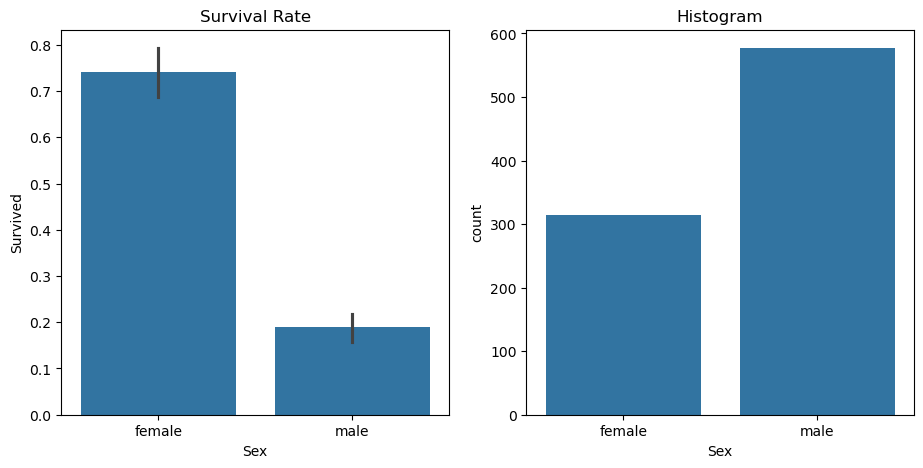

In [28]:
import seaborn as sns
import matplotlib.pyplot as plt

fig,axs = plt.subplots(1,2,figsize=(11,5))
sns.barplot(data=df, y=deps, x='Sex', ax=axs[0]).set(title='Survival Rate')
sns.countplot(data=df, x='Sex', ax=axs[1]).set(title='Histogram')